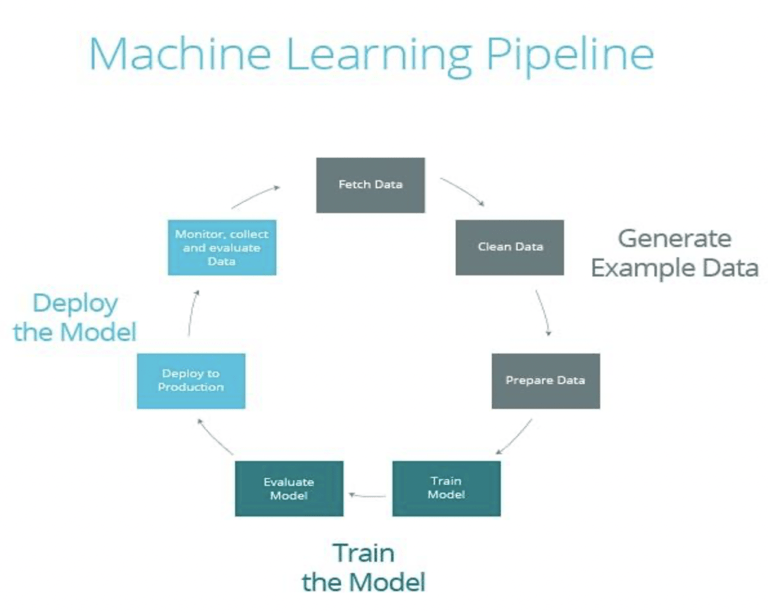

## ➿ Machine learning loop

### 🎒 Packages

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option('display.max_colwidth', None)
import random

from xgboost import XGBRegressor
import numpy as np

from sklearn.metrics import mean_squared_error, root_mean_squared_error
from xgboost import plot_tree
import xgboost as xgb
from xgboost import to_graphviz
import shap

---

### 🚙 Utilities

In [2]:
train_path = Path("..") / "data" / "train.csv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test.csv"
# store
store_path = Path("..") / "data" / "store.csv"

In [3]:
pastel_colors = sns.color_palette("pastel")

def color():
    color = random.choice(pastel_colors)
    return color

In [4]:
def feature_importance(model, type="gain", values=True):
    # model = models[2]
    #importance_type = "gain"
    plot_color = color()

    figsize = (10, 6)
    title = f"XGBoost Feature Importance ({type})"


    fig, ax = plt.subplots(figsize=figsize)

    xgb.plot_importance(
        booster=model,
        importance_type=type,
        ax=ax,
        color=plot_color,
        show_values=values
    )

    ax.set_title(title)
    ax.set_xlabel("Importance Score")
    ax.set_ylabel("Features")

    plt.tight_layout()
    plt.show()

---

### 📊 Data + Simple preprocessing to fill NA

#### 🫦 Problem of mixed types ✅

In [5]:
train = pd.read_csv(
    train_path,
    parse_dates=["Date"],
    dtype={"StateHoliday": "str"}
)

In [6]:
train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], low_memory=False)
test = pd.read_csv(filepath_or_buffer=test_path, parse_dates=["Date"])
store = pd.read_csv(filepath_or_buffer=store_path)

In [7]:
store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


#### 🎖️ Fill the NA with median on the competition distance

In [9]:
store["CompetitionDistance"] = store["CompetitionDistance"].fillna(store["CompetitionDistance"].median())

##### 🎖️ Fill the NAN of the Competition's open's month and year

In [10]:
# Assume that the competition opens for a very long day
# fill in that the competition has opened for a long term ago

year = store["CompetitionOpenSinceYear"].min()
store["CompetitionOpenSinceYear"] = store["CompetitionOpenSinceYear"].fillna(year)

store["CompetitionOpenSinceMonth"] = store["CompetitionOpenSinceMonth"].fillna(1)

#### 🎖️ Fill the NaN for the Promo2 (long-term promotion), when the promo2 == 0 -> Then features like year contain no meaning

In [11]:
# Fill sentinal
def sentimal_promo2(row):
    if row["Promo2"]:
        return row
    
    else:
        row["Promo2SinceWeek"] = -1
        row["Promo2SinceYear"] = -1
        row["PromoInterval"] = ""
        return row
        

store = store.apply(sentimal_promo2, axis=1)

In [12]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1115 non-null   float64
 4   CompetitionOpenSinceMonth  1115 non-null   float64
 5   CompetitionOpenSinceYear   1115 non-null   float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            1115 non-null   float64
 8   Promo2SinceYear            1115 non-null   float64
 9   PromoInterval              1115 non-null   str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [13]:
train.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [14]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


In [15]:
train["StateHoliday"].describe()

count     1017209
unique          4
top             0
freq       986159
Name: StateHoliday, dtype: object

In [16]:
test.head(5)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


---

### 🥼 Feature engineerings

##### 🈂️ Merge train and store, each record = sale on that day and the store's information

In [17]:
df = train.merge(store, on="Store", how="left")

In [18]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,-1.0,-1.0,
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,-1.0,-1.0,
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,-1.0,-1.0,


##### 🦢 Date features

In [19]:
# convert Date into Dates (for processing)
df["Date"] = pd.to_datetime(df["Date"])

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekofyear"] = df["Date"].dt.isocalendar().week
df["is_weekend"] = df["DayOfWeek"].isin([6,7]).astype(int)

In [20]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,-1.0,-1.0,,2015,7,31,31,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,-1.0,-1.0,,2015,7,31,31,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,-1.0,-1.0,,2015,7,31,31,0


#### 🔩 Competition duration

In [21]:
# calculate the number of months that the competition store has opened
df["CompetitionOpenSince"] = (
    (df["year"] - df["CompetitionOpenSinceYear"]) * 12 +
    (df["month"] - df["CompetitionOpenSinceMonth"])
)
df["CompetitionOpenSince"] = df["CompetitionOpenSince"].clip(lower=0)

In [22]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,0,-1.0,-1.0,,2015,7,31,31,0,82.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,0,-1.0,-1.0,,2015,7,31,31,0,70.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,0,-1.0,-1.0,,2015,7,31,31,0,3.0


#### 🧾 Promo2 (long-term impact)

In [23]:
# Calculate the number of weeks that the promo2 has been applied
df["Promo2Since"] = (
    (df["year"] - df["Promo2SinceYear"]) * 52 +
    (df["weekofyear"] - df["Promo2SinceWeek"])
)
df["Promo2Since"] = df["Promo2Since"].clip(lower=0)

In [24]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,-1.0,-1.0,,2015,7,31,31,0,82.0,104864.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,-1.0,-1.0,,2015,7,31,31,0,70.0,104864.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,-1.0,-1.0,,2015,7,31,31,0,3.0,104864.0


In [25]:
month_str = df["Date"].dt.strftime("%b")

# The current day is in the Promo2 or not
df["IsPromoMonth"] = df.apply(
    lambda x: 1 if isinstance(x["PromoInterval"], str) and month_str[x.name] in x["PromoInterval"] else 0,
    axis=1
)

In [26]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,-1.0,,2015,7,31,31,0,82.0,104864.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,-1.0,,2015,7,31,31,0,70.0,104864.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,-1.0,,2015,7,31,31,0,3.0,104864.0,0


#### 🗼 One hot encoding for categorical columns

In [27]:
# Convert labels into simple labels
for col in ["StoreType", "Assortment", "StateHoliday"]:
    df[col] = df[col].astype("category").cat.codes

In [28]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,-1.0,,2015,7,31,31,0,82.0,104864.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,-1.0,,2015,7,31,31,0,70.0,104864.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,-1.0,,2015,7,31,31,0,3.0,104864.0,0


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 26 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  int8          
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  int8          
 10  Assortment                 1017209 non-null  int8          
 11  CompetitionDistance        1017209 non-null  flo

#### 💫 Closed -> Sales = 0, we want the model to learn the Sales when store is open (pure), we don't want it to learn deterministic rules

In [30]:
df = df[df["Open"] == 1]

#### 🍰 No lag features now, meaning we just use the current information of the store to predict the current Sales

❌ Store's information contains NaN and Null values

In [31]:
df["Date"].min()

Timestamp('2013-01-01 00:00:00')

In [32]:
df["Date"].max()

Timestamp('2015-07-31 00:00:00')

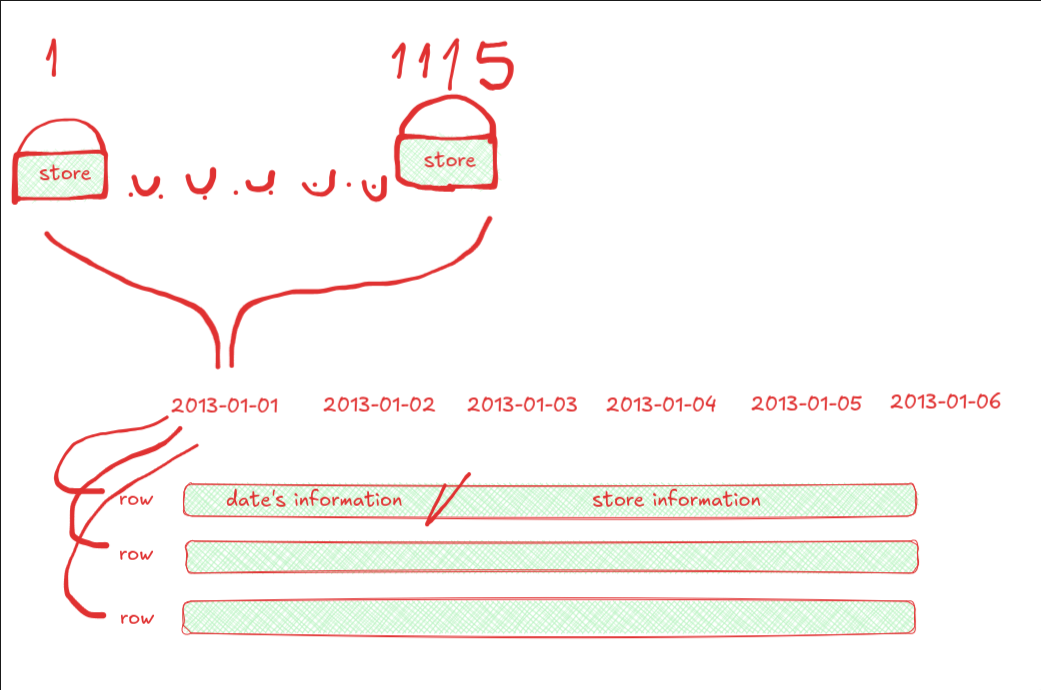

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  int8          
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  int8          
 10  Assortment                 844392 non-null  int8          
 11  CompetitionDistance        844392 non-null  float64       
 12  Com

In [34]:
df = df.sort_values(by=["Date", "Store"]).reset_index(drop=True)

In [35]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,85,2,2013-01-01,4220,619,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,15.0,104730.0,0
1,259,2,2013-01-01,6851,1444,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,1356.0,104730.0,0
2,262,2,2013-01-01,17267,2875,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,0.0,104730.0,0
3,274,2,2013-01-01,3102,729,1,0,1,1,1,...,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1,0,1356.0,0.0,1
4,335,2,2013-01-01,2401,482,1,0,1,1,1,...,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1,0,1356.0,0.0,1


#### 📧 Final features

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  int8          
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  int8          
 10  Assortment                 844392 non-null  int8          
 11  CompetitionDistance        844392 non-null  float64       
 12 

In [37]:
features = [
 "Store",                      # 844392 non-null  int64         
 "DayOfWeek",                  # 844392 non-null  int64         
 ########
 # Date                # 844392 non-null  datetime64[us]
 ########
 # 3   Sales                      # 844392 non-null  int64         
 # 4   Customers                  # 844392 non-null  int64         
 # 5   Open                       # 844392 non-null  int64         
 "Promo",                      # 844392 non-null  int64         
 "StateHoliday",               # 844392 non-null  int8          
 "SchoolHoliday",              # 844392 non-null  int64         
 "StoreType",                  # 844392 non-null  int8          
 "Assortment",                 # 844392 non-null  int8          
 "CompetitionDistance",        # 844392 non-null  float64       
 # 12  CompetitionOpenSinceMonth  # 575773 non-null  float64       
 # 13  CompetitionOpenSinceYear   # 575773 non-null  float64       
 "Promo2",                     # 844392 non-null  int64         
 # 15  Promo2SinceWeek            # 421085 non-null  float64       
 # 16  Promo2SinceYear            # 421085 non-null  float64       
 # 17  PromoInterval              # 421085 non-null  str           
 "year",                       # 844392 non-null  int32         
 "month",                      # 844392 non-null  int32         
 "day",                        # 844392 non-null  int32         
 "weekofyear",                 # 844392 non-null  UInt32        
 "is_weekend",                 # 844392 non-null  int64         
 "CompetitionOpenSince",       # 575773 non-null  float64       
 "Promo2Since",                # 421085 non-null  Float64       
 "IsPromoMonth",               # 844392 non-null  int64   
]

target = [
    "Sales"
]

In [38]:
X = df[features]
y = df[target]

### 🌵 Data spliting

#### 💦 Applying expand window cross validation

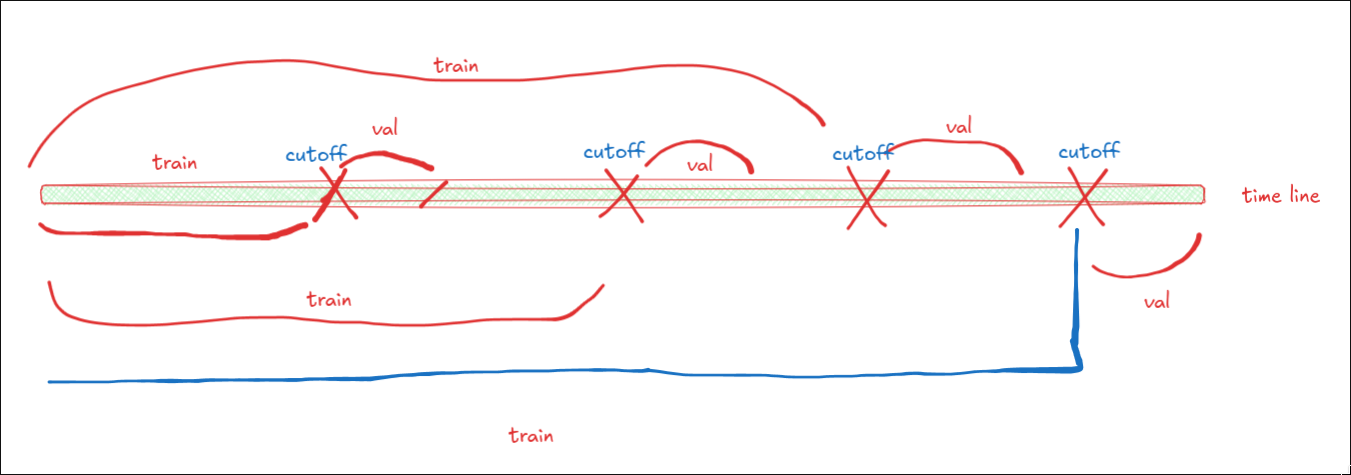

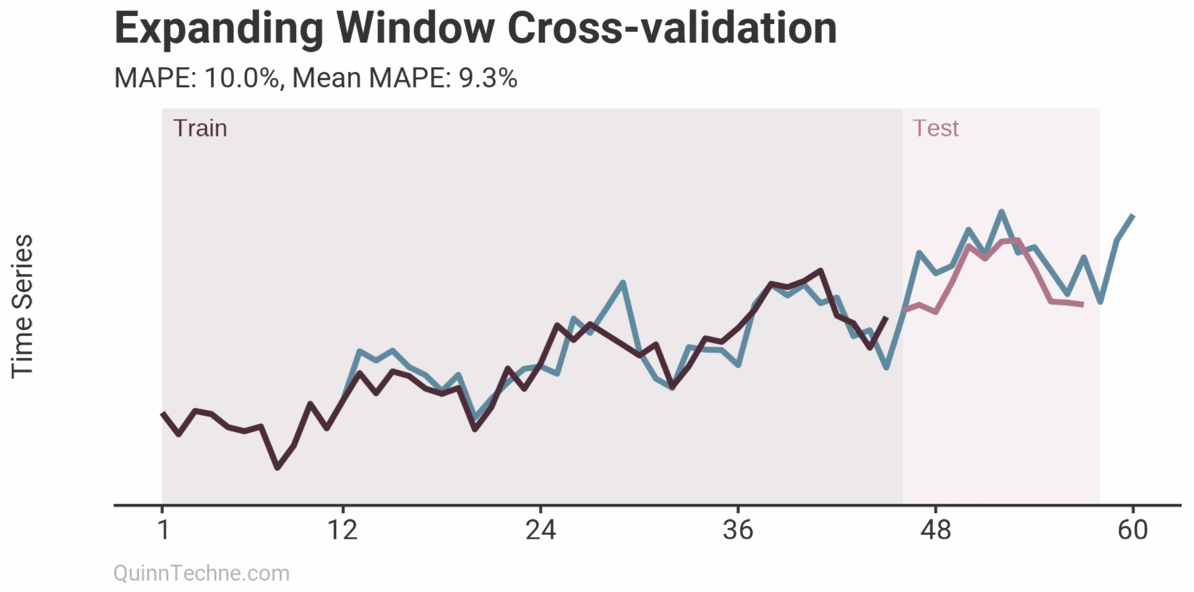

In [39]:
df.sort_values(by=["Date", "Store"]).reset_index(drop=True)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,85,2,2013-01-01,4220,619,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,15.0,104730.0,0
1,259,2,2013-01-01,6851,1444,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,1356.0,104730.0,0
2,262,2,2013-01-01,17267,2875,1,0,1,1,1,...,-1.0,,2013,1,1,1,0,0.0,104730.0,0
3,274,2,2013-01-01,3102,729,1,0,1,1,1,...,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1,0,1356.0,0.0,1
4,335,2,2013-01-01,2401,482,1,0,1,1,1,...,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1,0,1356.0,0.0,1


In [40]:
val_days = 42
n_folds = 4

X = df[features]
y = df["Sales"]

In [41]:
def create_expanding_folds_with_cutoffs(
    # X,
    # y,
    df,
    date_col="Date",
    cutoffs=None,
    val_days=42,
):
    # df = df.sort_values(date_col).reset_index(drop=True)

    # convert cutoffs into datetime
    cutoffs = [pd.to_datetime(c) for c in cutoffs]

    folds = []

    for i, cutoff in enumerate(cutoffs):
        # start = cutoff
        val_start = cutoff
        # end = cutoff + 42
        val_end = cutoff + pd.Timedelta(days=val_days)

        train = df[df[date_col] < val_start]
        val = df[(df[date_col] >= val_start) & (df[date_col] < val_end)]
        
        folds.append(
            (
                train,
                val
            )
        )

    return folds

In [73]:
def generate_rolling_folds(df, start, end, train_start=None, horizon=42, step=42):
    folds = []

    df = df.sort_values("Date").reset_index(drop=True)

    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    if train_start is None:
        train_start = start
    else:
        train_start = pd.to_datetime(train_start)

    current_cutoff = train_start

    while current_cutoff + pd.Timedelta(days=horizon) <= end:
        train = df[df["Date"] < current_cutoff]
        val = df[
            (df["Date"] >= current_cutoff) &
            (df["Date"] < current_cutoff + pd.Timedelta(days=horizon))
        ]

        folds.append((train, val))
        current_cutoff += pd.Timedelta(days=step)

    return folds

In [43]:
cutoffs = [
    "2014-03-01",
    "2014-06-01",
    "2014-09-01",
    "2014-12-01",
    "2015-06-20"
]

folds = create_expanding_folds_with_cutoffs(df, cutoffs=cutoffs)

### 🧹 Modeling

##### 🧾 On average, how big is my prediction error as a percentage of the true value?

In [74]:
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

In [75]:
folds = generate_rolling_folds(
    df,
    start="2013-01-01",
    end="2015-07-31",
    train_start="2013-06-01",
    horizon=42,
    step=42
)

In [77]:
def safe_rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # only calculate when sales > -
    mask = y_true > 0

    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

In [78]:
features = features

In [79]:
models = []
scores = []

for i, (train_df, val_df) in enumerate(folds):

    print(f"\nFold {i+1}")

    X_train = train_df[features]
    # Take logs
    # y_train = np.log1p(train_df[target])
    y_train = np.log1p(train_df[target]).values.ravel()

    X_val = val_df[features]
    # y_val = np.log1p(val_df["Sales"])
    #y_val = np.array(val_df[target])
    y_val = val_df[target].values.ravel()  

    model = XGBRegressor(
        # n_estimators=300,
        # max_depth=8,
        # learning_rate=0.05,
        # subsample=0.8,
        # colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    
    # convert preds back
    y_pred = np.expm1(preds)
    
    # print(type(y_val))
    # print(type(y_pred))

    metric = safe_rmspe(y_val, y_pred)
    scores.append(metric)

    print(f"RMSPE: {metric:.4f}")

    models.append(model)


Fold 1
RMSPE: 0.4458

Fold 2
RMSPE: 0.2036

Fold 3
RMSPE: 0.2498

Fold 4
RMSPE: 0.2100

Fold 5
RMSPE: 0.2596

Fold 6
RMSPE: 0.2362

Fold 7
RMSPE: 0.2483

Fold 8
RMSPE: 0.2025

Fold 9
RMSPE: 0.2320

Fold 10
RMSPE: 0.2071

Fold 11
RMSPE: 0.1964

Fold 12
RMSPE: 0.1913

Fold 13
RMSPE: 0.5657

Fold 14
RMSPE: 0.2441

Fold 15
RMSPE: 0.2720

Fold 16
RMSPE: 0.1862

Fold 17
RMSPE: 0.1929

Fold 18
RMSPE: 0.2306


### 🎃 Evaluation

In [80]:
mean_rmspe = np.mean(np.array(scores))
mean_rmspe

np.float64(0.2541026708395952)

In [49]:
plt.figure(figsize=(20, 10))

dot = to_graphviz(models[1], tree_idx=0)

dot.render("xgb_tree", format="png", cleanup=True)
plt.show()

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.578554 to fit


<Figure size 2000x1000 with 0 Axes>

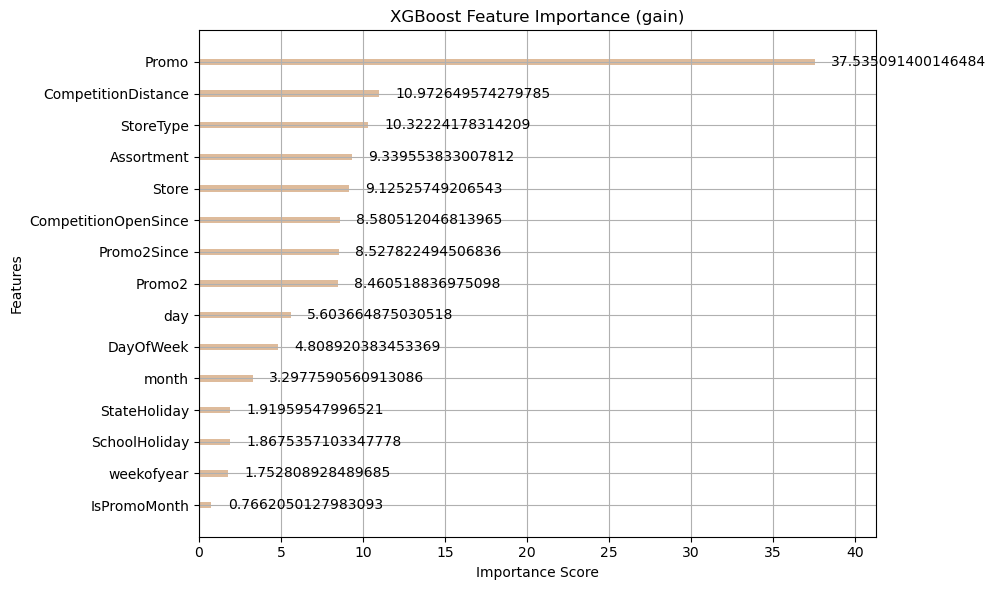

In [83]:
feature_importance(
    model=models[1]
)

In [51]:
# explainer = shap.TreeExplainer(models[1])
# shap_values = explainer.shap_values(X)

# shap.summary_plot(shap_values, X)

### 🔕 Back feature engineering - Lag features

In [52]:
df_1 = df.copy()

In [53]:
df_1 = df_1.sort_values(by=["Date", "Store"])

#### 🔙 Lag 1 - Sales from yesterday (same Store)

##### 🕌 What happened recently?

In [54]:
df_1["lag_1"] = df_1.groupby("Store")["Sales"].shift(1)
df_1["lag_1"] = df_1["lag_1"].fillna(df_1["lag_1"].median())

#### 🈲 Lag 7 - Sales from last week

In [55]:
df_1["lag_7"] = df_1.groupby("Store")["Sales"].shift(7)
df_1["lag_7"] = df_1["lag_7"].fillna(df_1["lag_7"].median())

#### 🈂️ Lag 14 - Sales from last 2 weeks

In [56]:
df_1["lag_14"] = df_1.groupby("Store")["Sales"].shift(14)
df_1["lag_14"] = df_1["lag_14"].fillna(df_1["lag_14"].median())

In [57]:
df_1.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth,lag_1,lag_7,lag_14
0,85,2,2013-01-01,4220,619,1,0,1,1,1,...,1,1,1,0,15.0,104730.0,0,6366.0,6360.0,6366.0
1,259,2,2013-01-01,6851,1444,1,0,1,1,1,...,1,1,1,0,1356.0,104730.0,0,6366.0,6360.0,6366.0
2,262,2,2013-01-01,17267,2875,1,0,1,1,1,...,1,1,1,0,0.0,104730.0,0,6366.0,6360.0,6366.0
3,274,2,2013-01-01,3102,729,1,0,1,1,1,...,1,1,1,0,1356.0,0.0,1,6366.0,6360.0,6366.0
4,335,2,2013-01-01,2401,482,1,0,1,1,1,...,1,1,1,0,1356.0,0.0,1,6366.0,6360.0,6366.0


In [58]:
features_1 = [
 "Store",                      # 844392 non-null  int64         
 "DayOfWeek",                  # 844392 non-null  int64         
 ########
 # Date                # 844392 non-null  datetime64[us]
 ########
 # 3   Sales                      # 844392 non-null  int64         
 # 4   Customers                  # 844392 non-null  int64         
 # 5   Open                       # 844392 non-null  int64         
 "Promo",                      # 844392 non-null  int64         
 "StateHoliday",               # 844392 non-null  int8          
 "SchoolHoliday",              # 844392 non-null  int64         
 "StoreType",                  # 844392 non-null  int8          
 "Assortment",                 # 844392 non-null  int8          
 "CompetitionDistance",        # 844392 non-null  float64       
 # 12  CompetitionOpenSinceMonth  # 575773 non-null  float64       
 # 13  CompetitionOpenSinceYear   # 575773 non-null  float64       
 "Promo2",                     # 844392 non-null  int64         
 # 15  Promo2SinceWeek            # 421085 non-null  float64       
 # 16  Promo2SinceYear            # 421085 non-null  float64       
 # 17  PromoInterval              # 421085 non-null  str           
 "year",                       # 844392 non-null  int32         
 "month",                      # 844392 non-null  int32         
 "day",                        # 844392 non-null  int32         
 "weekofyear",                 # 844392 non-null  UInt32        
 "is_weekend",                 # 844392 non-null  int64         
 "CompetitionOpenSince",       # 575773 non-null  float64       
 "Promo2Since",                # 421085 non-null  Float64       
 "IsPromoMonth",               # 844392 non-null  int64
 "lag_1",
 "lag_7",
 "lag_14",
]

target_1 = [
    "Sales"
]

#### 🥼 Retrain and evaluate

In [59]:
cutoffs = [
    "2014-03-01",
    "2014-06-01",
    "2014-09-01",
    "2014-12-01",
    "2015-06-20"
]

folds = create_expanding_folds_with_cutoffs(
        df_1, 
        cutoffs=cutoffs
    )

In [85]:
folds = generate_rolling_folds(
    df_1,
    start="2013-01-01",
    end="2015-07-31",
    train_start="2013-06-01",
    horizon=42,
    step=42
)

In [86]:
models = []
scores = []
XtXvytyv = []

for i, (train_df, val_df) in enumerate(folds):
    print(f"\n💯 Fold {i+1}")

    X_train = train_df[features_1]
    # Take logs
    # y_train = np.log1p(train_df[target])
    y_train_return = train_df[target_1].values.ravel()
    # train on log
    y_train = np.log1p(train_df[target_1]).values.ravel()

    X_val = val_df[features_1]
    # y_val = np.log1p(val_df["Sales"])
    #y_val = np.array(val_df[target])
    y_val = val_df[target_1].values.ravel()  
    
    XtXvytyv.append(
        (X_train, X_val, y_train_return, y_val)
    )

    model = XGBRegressor(
        # n_estimators=300,
        # max_depth=8,
        # learning_rate=0.05,
        # subsample=0.8,
        # colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    
    # convert preds back
    y_pred = np.expm1(preds)
    
    # print(type(y_val))
    # print(type(y_pred))

    metric = safe_rmspe(y_val, y_pred)
    scores.append(metric)

    print(f"RMSPE: {metric:.4f}")

    models.append(model)


💯 Fold 1
RMSPE: 0.5096

💯 Fold 2
RMSPE: 0.1668

💯 Fold 3
RMSPE: 0.2099

💯 Fold 4
RMSPE: 0.2150

💯 Fold 5
RMSPE: 0.2769

💯 Fold 6
RMSPE: 0.2746

💯 Fold 7
RMSPE: 0.2335

💯 Fold 8
RMSPE: 0.1825

💯 Fold 9
RMSPE: 0.2393

💯 Fold 10
RMSPE: 0.1679

💯 Fold 11
RMSPE: 0.1583

💯 Fold 12
RMSPE: 0.2666

💯 Fold 13
RMSPE: 0.4933

💯 Fold 14
RMSPE: 0.2593

💯 Fold 15
RMSPE: 0.2640

💯 Fold 16
RMSPE: 0.1559

💯 Fold 17
RMSPE: 0.2014

💯 Fold 18
RMSPE: 0.1839


In [87]:
mean_rmspe = np.mean(np.array(scores))
mean_rmspe

np.float64(0.2477079809679156)

In [62]:
# def feature_importance(mode, type="gain"):
#     # model = models[2]
#     #importance_type = "gain"
#     plot_color = color()

#     figsize = (10, 6)
#     title = f"XGBoost Feature Importance ({type})"


#     fig, ax = plt.subplots(figsize=figsize)

#     xgb.plot_importance(
#         booster=model,
#         importance_type=type,
#         ax=ax,
#         color=plot_color,
#         show_values=True
#     )

#     ax.set_title(title)
#     ax.set_xlabel("Importance Score")
#     ax.set_ylabel("Features")

#     plt.tight_layout()
#     plt.show()

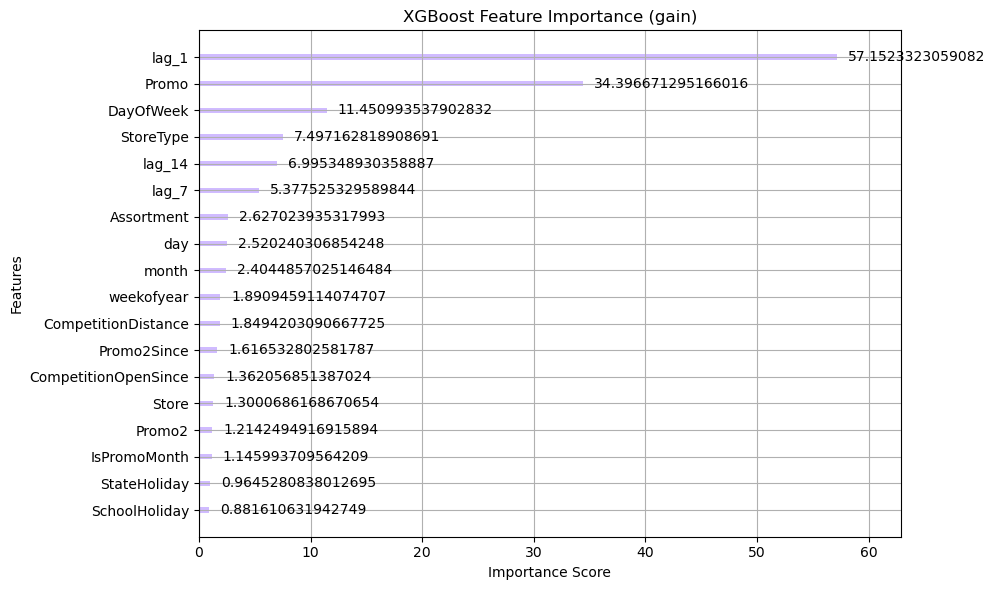

In [88]:
feature_importance(models[2])

### 🔙 Back to feature engineering - Rolling features

In [64]:
df_2 = df_1.copy()

#### 🪮 Create lag_1

In [65]:
df_2 = df_2.sort_values(["Store", "Date"])
df_2["lag_1"] = df_2.groupby("Store")["Sales"].shift(1)

# Fill NA
df_2["lag_1"] = df_2["lag_1"].fillna(df_2["lag_1"].median())

#### 🥼 Rolling_7 - not include current value

In [66]:
df_2["roll_mean_7"] = (
    df_2.groupby("Store")["lag_1"]
    .rolling(window=7)
    .mean()
    .reset_index(level=0, drop=True)
)
df_2["roll_mean_7"] = df_2["roll_mean_7"].fillna(df_2["roll_mean_7"].median())

df_2["roll_std_7"] = (
    df_2.groupby("Store")["lag_1"]
    .rolling(window=7)
    .std()
    .reset_index(level=0, drop=True)
)
df_2["roll_std_7"] = df_2["roll_std_7"].fillna(df_2["roll_std_7"].median())

#### 🙄 Rolling_14 - not include current value

In [67]:
df_2["roll_mean_14"] = (
    df_2.groupby("Store")["lag_1"]
    .rolling(window=14)
    .mean()
    .reset_index(level=0, drop=True)
)
df_2["roll_mean_14"] = df_2["roll_mean_14"].fillna(df_2["roll_mean_14"].median())

df_2["roll_std_14"] = (
    df_2.groupby("Store")["lag_1"]
    .rolling(window=14)
    .std()
    .reset_index(level=0, drop=True)
)
df_2["roll_std_14"] = df_2["roll_std_14"].fillna(df_2["roll_std_14"].median())

#### 🚆 Model training

In [68]:
features_2 = [f for f in features_1] + [
    "roll_mean_7",
    "roll_std_7",
    "roll_mean_14",
    "roll_std_14"
]

target_2 = [
    "Sales"
]

#### ❇️ Data spliting for training and evaluation

In [69]:
cutoffs = [
    "2014-03-01",
    "2014-06-01",
    "2014-09-01",
    "2014-12-01",
    "2015-06-20"
]

folds = create_expanding_folds_with_cutoffs(
        df_2, 
        cutoffs=cutoffs
    )

In [89]:
folds = generate_rolling_folds(
    df_2,
    start="2013-01-01",
    end="2015-07-31",
    train_start="2013-06-01",
    horizon=42,
    step=42
)

In [90]:
models = []
scores = []
XtXvytyv = []

for i, (train_df, val_df) in enumerate(folds):
    print(f"\n💯 Fold {i+1}")

    X_train = train_df[features_2]
    # Take logs
    # y_train = np.log1p(train_df[target])
    y_train_return = train_df[target_2].values.ravel()
    # train on log
    y_train = np.log1p(train_df[target_2]).values.ravel()

    X_val = val_df[features_2]
    # y_val = np.log1p(val_df["Sales"])
    #y_val = np.array(val_df[target])
    y_val = val_df[target_2].values.ravel()  
    
    XtXvytyv.append(
        (X_train, X_val, y_train_return, y_val)
    )

    model = XGBRegressor(
        # n_estimators=300,
        # max_depth=8,
        # learning_rate=0.05,
        # subsample=0.8,
        # colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    
    # convert preds back
    y_pred = np.expm1(preds)
    
    # print(type(y_val))
    # print(type(y_pred))

    metric = safe_rmspe(y_val, y_pred)
    scores.append(metric)

    print(f"RMSPE: {metric:.4f}")

    models.append(model)


💯 Fold 1
RMSPE: 0.4605

💯 Fold 2
RMSPE: 0.1431

💯 Fold 3
RMSPE: 0.1896

💯 Fold 4
RMSPE: 0.2175

💯 Fold 5
RMSPE: 0.2554

💯 Fold 6
RMSPE: 0.3261

💯 Fold 7
RMSPE: 0.2144

💯 Fold 8
RMSPE: 0.1638

💯 Fold 9
RMSPE: 0.1941

💯 Fold 10
RMSPE: 0.1580

💯 Fold 11
RMSPE: 0.1422

💯 Fold 12
RMSPE: 0.1351

💯 Fold 13
RMSPE: 0.5581

💯 Fold 14
RMSPE: 0.2024

💯 Fold 15
RMSPE: 0.2218

💯 Fold 16
RMSPE: 0.1374

💯 Fold 17
RMSPE: 0.1754

💯 Fold 18
RMSPE: 0.1512


#### 🧏‍♀️ Evaluation

In [91]:
mean_rmspe = np.mean(np.array(scores))
mean_rmspe

np.float64(0.2247902470188364)

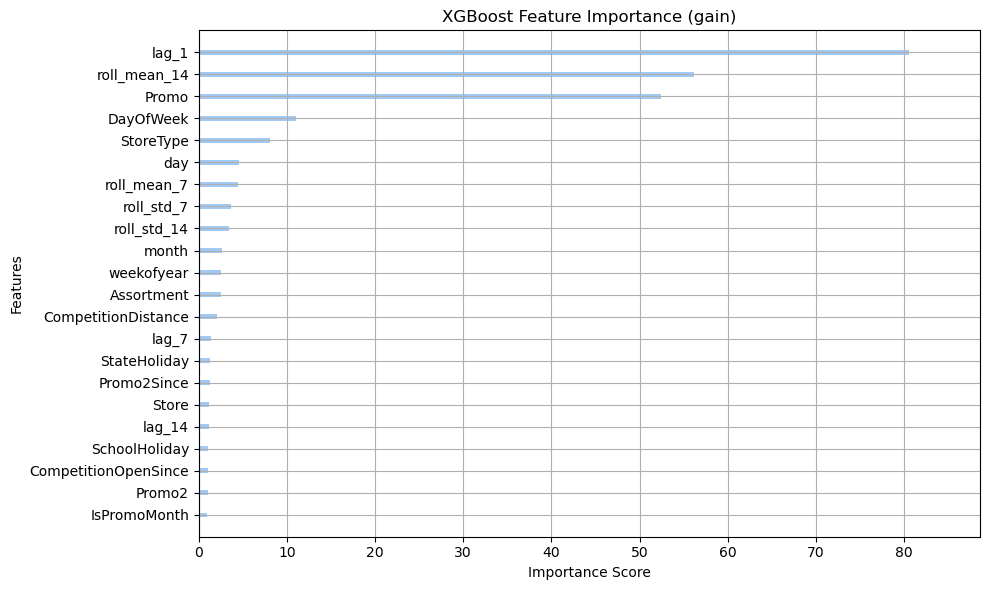

In [93]:
feature_importance(models[4], values=False)